# Fractional Differencing

**Docker image**: `ml4t`

This notebook demonstrates **fractional differentiation** (FFD), a technique that
achieves stationarity while preserving as much memory as possible.

**Learning Objectives**:
- Understand the memory-stationarity tradeoff controlled by $d \in (0, 1)$
- Compute FFD weights and apply fractional differencing via ml4t-engineer
- Select $d$ by asset class using bounded grids (no in-sample search)
- Validate stationarity with ADF and quantify sample loss

**Book Reference**: Chapter 9, Section 9.1 (Diagnostics and Stationarity Features)

**Prerequisites**: `01_visual_diagnostics` for stationarity testing concepts.

In [1]:
"""Fractional Differencing — achieve stationarity while preserving memory."""

import warnings
from typing import Any, cast

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

from ml4t.engineer.features.fdiff import (
    fdiff_diagnostics,
    ffdiff,
    find_optimal_d,
    get_ffd_weights,
)

from data import load_etfs

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"

In [3]:
# Load data
all_etfs = load_etfs()

## 1. Load Data

In [4]:
def load_etf_data(symbol: str, start: str = START_DATE, end: str = END_DATE) -> pl.DataFrame:
    """Load ETF data from cached parquet."""
    df = (
        all_etfs.filter(pl.col("symbol") == symbol)
        .filter(pl.col("timestamp") >= pl.lit(start).str.to_date())
        .filter(pl.col("timestamp") <= pl.lit(end).str.to_date())
        .sort("timestamp")
    )
    return df


# Load SPY for demonstration
spy = load_etf_data("SPY")
print(f"SPY: {len(spy)} days")

SPY: 2264 days


## 2. Bounded d Grid (Default Workflow)

Rather than searching for "optimal d", use **fixed grids by asset class**.
This is simpler, more robust, and avoids overfitting to in-sample data.

### Recommended d Values by Asset Class

| Asset Class | Recommended d | Rationale |
|-------------|---------------|-----------|
| **US Equities** | 0.4 | Moderate persistence |
| **Fixed Income** | 0.5 | High persistence (rates) |
| **Crypto** | 0.5-0.6 | Strong trending |
| **Commodities** | 0.4 | Similar to equities |
| **FX** | 0.3-0.4 | Mean-reverting tendency |

These are starting points. The exact value matters less than being consistent
and avoiding lookahead from searching on the full sample.

In [5]:
# Asset class d recommendations
ASSET_CLASS_D = {
    "equities": 0.4,
    "fixed_income": 0.5,
    "crypto": 0.5,
    "commodities": 0.4,
    "fx": 0.35,
}

# For teaching: small fixed grid (not search)
TEACHING_D_GRID = [0.3, 0.4, 0.5, 0.6]

print("Asset Class d Recommendations:")
for asset, d in ASSET_CLASS_D.items():
    print(f"  {asset:15s}: d = {d}")

Asset Class d Recommendations:
  equities       : d = 0.4
  fixed_income   : d = 0.5
  crypto         : d = 0.5
  commodities    : d = 0.4
  fx             : d = 0.35


## 3. FFD with Validity Mask and Sample Loss

The standard output format includes:
- **transformed**: The FFD series
- **valid**: Boolean mask (True where FFD is computable)
- **sample_loss**: Number of observations lost to warmup

In [6]:
def ffd_with_diagnostics(
    series: pl.Series, d: float, threshold: float = 1e-5
) -> dict[str, pl.Series | int | float]:
    """
    Apply FFD and return transformed series with validity mask and diagnostics.

    Parameters
    ----------
    series : pl.Series
        Input series (typically log prices)
    d : float
        Differentiation order
    threshold : float
        Weight cutoff threshold

    Returns
    -------
    dict with:
        - transformed: FFD series
        - valid: Boolean mask
        - sample_loss: Number of NaN observations
        - d: The d value used
        - n_weights: Number of FFD weights
    """
    # Get weights to determine warmup period
    weights = get_ffd_weights(d, threshold=threshold)
    n_weights = len(weights)

    # Apply FFD
    ffd_series = ffdiff(series, d=d, threshold=threshold)

    # Create validity mask
    arr = ffd_series.to_numpy()
    valid = ~np.isnan(arr)

    # Count sample loss
    sample_loss = np.sum(~valid)

    return {
        "transformed": ffd_series,
        "valid": pl.Series("valid", valid),
        "sample_loss": sample_loss,
        "d": d,
        "n_weights": n_weights,
    }

In [7]:
# Apply FFD to SPY log prices with recommended d for equities
log_prices = spy["close"].log()
d_equity = ASSET_CLASS_D["equities"]

ffd_result = ffd_with_diagnostics(log_prices, d=d_equity)
ffd_valid = cast(pl.Series, ffd_result["valid"])
ffd_transformed = cast(pl.Series, ffd_result["transformed"])

print(f"FFD Results (d={d_equity}):")
print(f"  Total observations: {len(log_prices)}")
print(f"  Valid observations: {ffd_valid.sum()}")
print(
    f"  Sample loss: {ffd_result['sample_loss']} ({100 * ffd_result['sample_loss'] / len(log_prices):.1f}%)"
)
print(f"  FFD weights used: {ffd_result['n_weights']}")

FFD Results (d=0.4):
  Total observations: 2264
  Valid observations: 2264
  Sample loss: 0 (0.0%)
  FFD weights used: 1458


## 4. Compare d Values from Grid

Show how different d values affect stationarity and memory preservation.

In [8]:
# Apply grid of d values
grid_results = {}

for d in TEACHING_D_GRID:
    result = ffd_with_diagnostics(log_prices, d=d)
    transformed = cast(pl.Series, result["transformed"])
    valid = cast(pl.Series, result["valid"])

    # Quick stationarity check (for display only)
    clean = transformed.drop_nulls().to_numpy()
    if len(clean) > 50:
        adf_stat, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")

        # Correlation with original (memory preserved)
        valid_mask = valid.to_numpy()
        orig = log_prices.to_numpy()[valid_mask]
        ffd = transformed.to_numpy()[valid_mask]
        corr = np.corrcoef(orig, ffd)[0, 1]

        grid_results[d] = {
            "sample_loss": result["sample_loss"],
            "adf_pval": adf_pval,
            "correlation": corr,
            "n_weights": result["n_weights"],
        }

grid_df = pd.DataFrame(
    [
        {
            "d": d,
            "sample_loss": res["sample_loss"],
            "adf_pval": res["adf_pval"],
            "stationary": res["adf_pval"] < 0.05,
            "corr_with_orig": res["correlation"],
            "n_weights": res["n_weights"],
        }
        for d, res in grid_results.items()
    ]
)
display(grid_df)

,d,sample_loss,adf_pval,stationary,corr_with_orig,n_weights
0,0.3,0,1.177846e-19,True,-0.524725,2275
1,0.4,0,8.328753e-19,True,-0.418547,1458
2,0.5,0,2.804332e-21,True,-0.282273,927
3,0.6,0,2.528302e-18,True,-0.174915,590


## 5. Visualize FFD Weights

FFD weights determine how much memory is preserved. Lower d = longer memory.

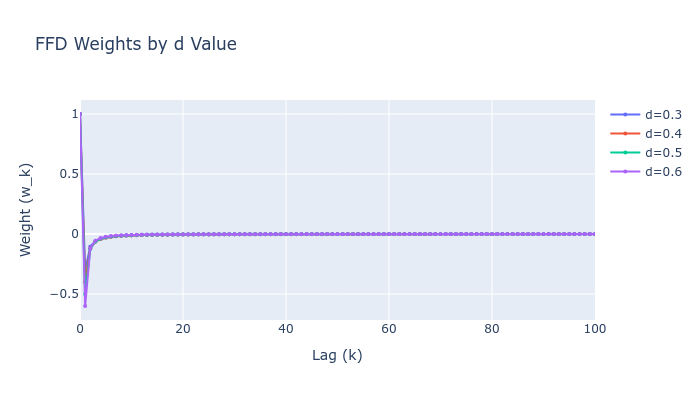


Weight Counts (threshold=1e-5):
  d=0.3: 2275 weights
  d=0.4: 1458 weights
  d=0.5: 927 weights
  d=0.6: 590 weights


In [9]:
# Visualize weights for different d values
fig = go.Figure()

for d in TEACHING_D_GRID:
    weights = get_ffd_weights(d, threshold=1e-5)
    fig.add_trace(
        go.Scatter(
            x=list(range(len(weights))),
            y=weights,
            mode="lines+markers",
            name=f"d={d}",
            marker=dict(size=4),
        )
    )

fig.update_layout(
    height=400,
    title="FFD Weights by d Value",
    xaxis_title="Lag (k)",
    yaxis_title="Weight (w_k)",
    # Cap x-axis at the first 100 lags — beyond that, weights decay below the
    # 1e-5 threshold and the curves crawl along zero, compressing the visible
    # decay structure near k=0 where the differences across d live.
    xaxis=dict(range=[0, 100]),
)
fig.show()

# Weight counts
print("\nWeight Counts (threshold=1e-5):")
for d in TEACHING_D_GRID:
    weights = get_ffd_weights(d, threshold=1e-5)
    print(f"  d={d}: {len(weights)} weights")

## 6. Feature Engineering Output Format

Standard format for downstream ML: transformed series + validity mask.

In [10]:
# Create feature table with FFD at recommended d
spy_features = spy.select(["timestamp", "close"]).with_columns(
    [
        pl.col("close").log().alias("log_close"),
        pl.col("close").pct_change().alias("return_1d"),
    ]
)

# Add FFD with recommended d
d_use = ASSET_CLASS_D["equities"]
ffd_result = ffd_with_diagnostics(spy_features["log_close"], d=d_use)
ffd_transformed = cast(pl.Series, ffd_result["transformed"])
ffd_valid = cast(pl.Series, ffd_result["valid"])

spy_features = spy_features.with_columns(
    [
        ffd_transformed.alias(f"ffd_{d_use}"),
        ffd_valid.alias("ffd_valid"),
    ]
)

# Show sample loss prominently
print(f"Feature Engineering Output (d={d_use}):")
print(f"  Total rows: {spy_features.height}")
print(f"  Valid rows: {ffd_valid.sum()}")
print(f"  Sample loss: {ffd_result['sample_loss']} observations")
print()

Feature Engineering Output (d=0.4):
  Total rows: 2264
  Valid rows: 2264
  Sample loss: 0 observations



The feature table below shows the last 10 valid rows. Note the `ffd_valid`
column — downstream ML pipelines should filter on this mask to exclude the
warmup period where FFD weights require more history than is available.

In [11]:
print("Feature Table (valid rows):")
spy_features.filter(pl.col("ffd_valid")).tail(10)

Feature Table (valid rows):


timestamp,close,log_close,return_1d,ffd_0.4,ffd_valid
date,f64,f64,f64,f64,bool
2023-12-15,456.760101,6.124158,-0.001647,0.251733,true
2023-12-18,459.329468,6.129768,0.005625,0.256018,true
2023-12-19,462.122559,6.13583,0.006081,0.258665,true
2023-12-20,455.718842,6.121876,-0.013857,0.240667,true
2023-12-21,460.039886,6.131313,0.009482,0.253813,true
2023-12-22,460.964417,6.133321,0.00201,0.252426,true
2023-12-26,462.910828,6.137534,0.004222,0.254589,true
2023-12-27,463.747833,6.139341,0.001808,0.253614,true
2023-12-28,463.923004,6.139719,0.000378,0.251948,true


## 7. Multi-Asset Application

Apply fixed d values by asset class (no search).

In [12]:
# ETF symbols with asset class mapping
ETF_ASSETS = {
    "SPY": "equities",
    "QQQ": "equities",
    "IWM": "equities",
    "TLT": "fixed_income",
    "GLD": "commodities",
    "EFA": "equities",
    "EEM": "equities",
}

etf_ffd_results = {}

for symbol, asset_class in ETF_ASSETS.items():
    data = load_etf_data(symbol)
    if data.height < 100:
        continue

    d = ASSET_CLASS_D[asset_class]
    log_prices = data["close"].log()
    result = ffd_with_diagnostics(log_prices, d=d)

    # Quick stationarity verification
    clean = cast(pl.Series, result["transformed"]).drop_nulls().to_numpy()
    if len(clean) > 50:
        _, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")

        etf_ffd_results[symbol] = {
            "asset_class": asset_class,
            "d": d,
            "sample_loss": result["sample_loss"],
            "sample_loss_pct": 100 * result["sample_loss"] / data.height,
            "adf_pval": adf_pval,
            "stationary": adf_pval < 0.05,
        }

When building a mixed-portfolio feature set, different asset classes will have
different optimal d values. This is acceptable — each security's FFD features
use its own d, and the ML model learns from the resulting feature distributions.
Consistency within each security over time matters more than uniformity across
securities.

In [13]:
multi_df = pd.DataFrame([{"symbol": sym, **res} for sym, res in etf_ffd_results.items()])
display(multi_df)

,symbol,asset_class,d,sample_loss,sample_loss_pct,adf_pval,stationary
0,SPY,equities,0.4,0,0.0,8.328753e-19,True
1,QQQ,equities,0.4,0,0.0,8.064936e-19,True
2,IWM,equities,0.4,0,0.0,2.070530e-16,True
3,TLT,fixed_income,0.5,0,0.0,2.849230e-10,True
4,GLD,commodities,0.4,0,0.0,2.851341e-11,True
5,EFA,equities,0.4,0,0.0,8.457089e-15,True
6,EEM,equities,0.4,0,0.0,1.543391e-16,True


## 8. Visualize FFD Transformation

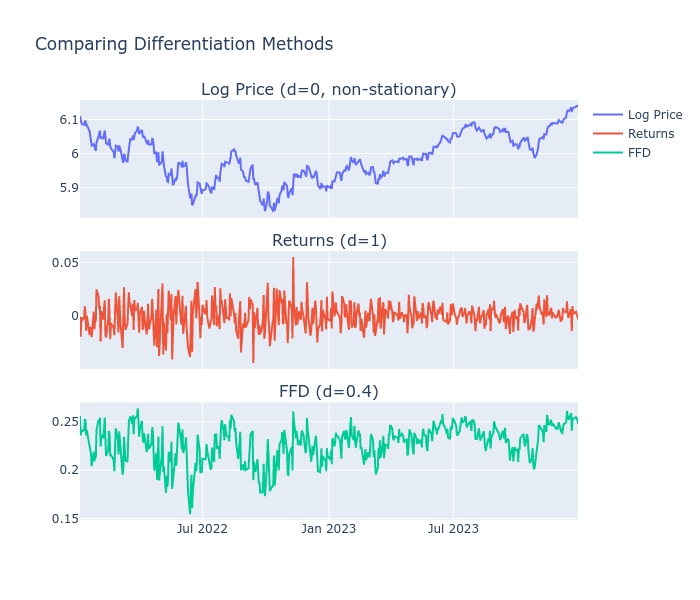

In [14]:
# Compare original, returns, and FFD
d_plot = ASSET_CLASS_D["equities"]
ffd_series = ffdiff(spy["close"].log(), d=d_plot)

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Log Price (d=0, non-stationary)", "Returns (d=1)", f"FFD (d={d_plot})"],
    vertical_spacing=0.08,
)

dates = spy["timestamp"].to_list()
log_prices_arr = spy["close"].log().to_numpy()
returns_arr = spy["close"].pct_change().to_numpy()
ffd_arr = ffd_series.to_numpy()

# Use last 500 points for visibility
n = 500

fig.add_trace(go.Scatter(x=dates[-n:], y=log_prices_arr[-n:], name="Log Price"), row=1, col=1)
fig.add_trace(go.Scatter(x=dates[-n:], y=returns_arr[-n:], name="Returns"), row=2, col=1)
fig.add_trace(go.Scatter(x=dates[-n:], y=ffd_arr[-n:], name="FFD"), row=3, col=1)

fig.update_layout(height=600, title="Comparing Differentiation Methods")
fig.show()

---

## 9. [OPTIONAL] Walk-Forward d Search

> **WARNING: Research Helper Only**
>
> If you need to search for d, do it with **walk-forward validation**:
> estimate d on training data only, then apply to test data.
> This avoids lookahead bias from using the full sample.

In [15]:
def find_d_walk_forward(
    series: pl.Series,
    train_end_idx: int,
    d_grid: list[float] | None = None,
    adf_threshold: float = 0.05,
) -> dict[str, Any]:
    """Find the smallest $d$ on the grid that makes the series stationary.

    Estimated on training data only — no leakage from the held-out tail. The
    smallest stationary $d$ is the López de Prado convention: keep as much
    long-run dependence as the stationarity diagnostic allows.
    """
    if d_grid is None:
        d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    train_series = series.head(train_end_idx)
    d_grid = sorted(d_grid)

    for d in d_grid:
        ffd_train = ffdiff(train_series, d=d)
        clean = ffd_train.drop_nulls().to_numpy()

        if len(clean) < 50:
            continue

        _, adf_pval, _, _, _, _ = adfuller(clean, autolag="AIC")
        if adf_pval < adf_threshold:
            valid = ~np.isnan(ffd_train.to_numpy())
            orig = train_series.to_numpy()[valid]
            ffd = ffd_train.to_numpy()[valid]
            corr = np.corrcoef(orig, ffd)[0, 1]
            return {
                "optimal_d": d,
                "train_adf_pval": adf_pval,
                "train_correlation": corr,
            }

    # No d on the grid produced a stationary series — fall back to first differences.
    return {"optimal_d": 1.0, "train_adf_pval": float("nan"), "train_correlation": 0.0}

In [16]:
# [OPTIONAL] Walk-forward example
# Split: 80% train, 20% test
train_pct = 0.8
train_end = int(len(spy) * train_pct)

print("Walk-forward d search:")
print(f"  Training period: {spy['timestamp'][0]} to {spy['timestamp'][train_end - 1]}")
print(f"  Test period: {spy['timestamp'][train_end]} to {spy['timestamp'][-1]}")
print()

wf_result = find_d_walk_forward(spy["close"].log(), train_end_idx=train_end)

print("Results (estimated on training data ONLY):")
print(f"  Selected d: {wf_result['optimal_d']}")
print(f"  Train ADF p-value: {wf_result['train_adf_pval']:.4f}")
print(f"  Train correlation with original: {wf_result['train_correlation']:.4f}")
print()

# Apply to test data (out-of-sample)
test_series = spy["close"].log().tail(len(spy) - train_end)
ffd_test = ffdiff(test_series, d=wf_result["optimal_d"])
clean_test = ffd_test.drop_nulls().to_numpy()

if len(clean_test) > 50:
    _, test_pval, _, _, _, _ = adfuller(clean_test, autolag="AIC")
    print("Out-of-sample verification:")
    print(f"  Test ADF p-value: {test_pval:.4f}")
    print(f"  Stationary in test: {'Yes' if test_pval < 0.05 else 'No'}")

Walk-forward d search:
  Training period: 2015-01-02 to 2022-03-11
  Test period: 2022-03-14 to 2023-12-29

Results (estimated on training data ONLY):
  Selected d: 0.1
  Train ADF p-value: 0.0000
  Train correlation with original: -0.2828

Out-of-sample verification:
  Test ADF p-value: 0.0000
  Stationary in test: Yes


### ml4t-engineer: Automated d Selection and Diagnostics

The manual walk-forward search above builds intuition for the
memory-stationarity tradeoff. For production use, `find_optimal_d()`
automates the grid search and `fdiff_diagnostics()` provides a
comprehensive diagnostic summary.

In [17]:
# find_optimal_d: automated grid search
log_prices_series = spy["close"].log()
optimal = find_optimal_d(log_prices_series, d_range=(0.0, 1.0), step=0.05)
print("=== ml4t-engineer: find_optimal_d ===")
print(f"Optimal d: {optimal['optimal_d']:.2f}")
print(f"ADF p-value: {optimal['adf_pvalue']:.4f}")
print(f"Correlation with original: {optimal['correlation']:.4f}")

=== ml4t-engineer: find_optimal_d ===
Optimal d: 0.05
ADF p-value: 0.0088
Correlation with original: 0.5642


In [18]:
# fdiff_diagnostics: detailed analysis at a specific d
diag = fdiff_diagnostics(log_prices_series, d=optimal["optimal_d"])
print("=== ml4t-engineer: fdiff_diagnostics ===")
print(f"d: {diag['d']:.2f}")
print(f"ADF statistic: {diag['adf_statistic']:.4f}")
print(f"ADF p-value: {diag['adf_pvalue']:.4f}")
print(f"Correlation: {diag['correlation']:.4f}")
print(f"Number of weights: {diag['n_weights']}")
print(f"Weight sum: {diag['weight_sum']:.4f}")

=== ml4t-engineer: fdiff_diagnostics ===
d: 0.05
ADF statistic: -3.4682
ADF p-value: 0.0088
Correlation: 0.5642
Number of weights: 3237
Weight sum: 1.3528


**Note**: For the recommended workflow, use **fixed d by asset class** (Section 2).
`find_optimal_d()` is a convenience for exploratory analysis — it searches the
full sample, so wrap it in a walk-forward scheme to avoid lookahead bias.

## 10. Distribution Comparison

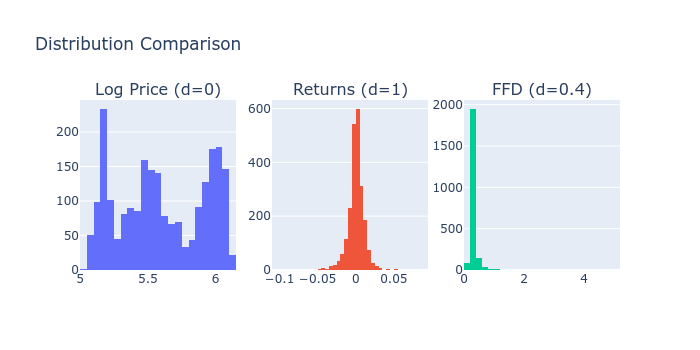

In [19]:
# Compare distributions of different transformations
d_compare = ASSET_CLASS_D["equities"]
ffd_compare = ffdiff(spy["close"].log(), d=d_compare)

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Log Price (d=0)", "Returns (d=1)", f"FFD (d={d_compare})"],
)

log_vals = spy["close"].log().drop_nulls().to_numpy()
ret_vals = spy["close"].pct_change().drop_nulls().to_numpy()
ffd_vals = ffd_compare.drop_nulls().to_numpy()

fig.add_trace(go.Histogram(x=log_vals, nbinsx=50, name="Log Price"), row=1, col=1)
fig.add_trace(go.Histogram(x=ret_vals, nbinsx=50, name="Returns"), row=1, col=2)
fig.add_trace(go.Histogram(x=ffd_vals, nbinsx=50, name="FFD"), row=1, col=3)

fig.update_layout(height=350, title="Distribution Comparison", showlegend=False)
fig.show()

**Finding**: The log price distribution (left) is multimodal and non-stationary.
Returns (center) are approximately symmetric with fat tails. The FFD series (right)
preserves more of the original series' shape than returns while achieving
stationarity — the key benefit of fractional differencing.

---

## Summary

### Default Workflow (Recommended)

1. **Use fixed d by asset class** - no search, no lookahead
2. **Output format**: transformed series + validity mask + sample loss count
3. **Verify stationarity** with quick ADF check (but don't optimize on it)

### Asset Class d Recommendations

| Asset Class | d |
|-------------|---|
| US Equities | 0.4 |
| Fixed Income | 0.5 |
| Crypto | 0.5 |
| Commodities | 0.4 |
| FX | 0.35 |

### Note on Sample Loss

`ml4t.engineer.features.fdiff.ffdiff` applies truncated weights at the start
of the series rather than NaN-padding a warmup region. The feature is
therefore non-null from observation 0 — the diagnostic tables above show
`Sample Loss = 0` for every ETF. Classical FFD as described in López de Prado
(2018) drops the warmup explicitly. Choose the convention deliberately when
building features: the truncated form keeps every observation but the
earliest values use only a partial weight set, while the warmup-dropping
form discards them.

### ml4t-engineer Functions

- **`ffdiff(series, d)`**: Apply fractional differentiation
- **`get_ffd_weights(d, threshold)`**: Get FFD weight vector
- **`find_optimal_d(series)`**: Automated grid search for minimum stationary d
- **`fdiff_diagnostics(series, d)`**: ADF, correlation, weight analysis at given d

### Key Points

1. **Always report sample loss** - FFD loses early observations
2. **Use validity mask** for downstream ML pipelines
3. **For walk-forward search** (optional): estimate d on training data only
4. **For stationarity testing details**: see `01_visual_diagnostics`

**Next**: See `04_kalman_filter` for signal transform features and
`05_spectral_features` for frequency-domain features.